In [581]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils

%matplotlib widget

In [582]:
# ============================================================
# Configuration
# ============================================================

# Mesh / geometry
PLT_FILE = "./cylinder.plt"
SURFACE_FLAG = 3     # out-of-plane surface (xy plane)

# Iteration files (change here only)
RHS_OLD_FILE = "rhs10000.txt"
RHS_NEW_FILE = "rhs10001.txt"

RST_OLD_FILE = "cylinder10000.rst"
RST_NEW_FILE = "cylinder10001.rst"

# Plot bounds
X_BOUNDS = (-4, 15)
Y_BOUNDS = (-4, 4)

# Jacobian component to plot (1-based indexing)
J_ROW = 1
J_COL = 1

EPS = 1e-10
GAMMA = 1.4

# ============================================================
# Direct Jacobian configuration
# ============================================================

JACOBIAN_FILE = "jacobian10001.txt"     # direct Jacobian file
PLOT_DIRECT_JACOBIAN = True           # master switch


In [583]:
def read_direct_jacobian(filename):
    """
    Reads jacobian.txt and reshapes it to (N, 5, 5)
    Assumes first column is index.
    """
    J_raw = pd.read_csv(
        filename,
        delim_whitespace=True,
        header=None
    ).to_numpy()

    # Drop index column and reshape
    J = J_raw[:, 1:].reshape(-1, 5, 5, order="F")
    return J


def extract_iteration(filename):
    """Extract integer iteration number from filename."""
    digits = "".join(filter(str.isdigit, filename))
    return int(digits) if digits else None


def read_rhs(filename):
    """Read RHS file and return numpy array without index column."""
    data = pd.read_csv(filename, delim_whitespace=True, header=None).to_numpy()
    return data[:, 1:]


def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)


def conservative_variables(rst, side_nodes):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))

    return U[side_nodes]


def setup_surface_triangulation(pltfile, x_bounds, y_bounds):
    """Extract surface, apply spatial filter, and build triangulation."""
    side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=SURFACE_FLAG)

    tmp_grp = GrpFileUtils(
        "tmp",
        0,
        read=False,
        coord=side_coords,
        nodes=side_nodes
    )
    tmp_grp.root_nodemap = side_nodemap

    x_lo, x_hi = x_bounds
    y_lo, y_hi = y_bounds

    node_filter = (
        (side_coords[:, 0] > x_lo) & (side_coords[:, 0] < x_hi) &
        (side_coords[:, 1] > y_lo) & (side_coords[:, 1] < y_hi)
    )

    tmp_grp.node_filter = node_filter

    tri_nodemap = tmp_grp.get_tri_nodemap()
    grp_x = tmp_grp.coords[:, 0]
    grp_y = tmp_grp.coords[:, 1]

    tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)

    return tri, side_nodes, node_filter


def plot_scalar_on_surface(tri, data, node_filter, title, label, x_bounds, y_bounds):
    fig, ax = plt.subplots()

    contour = ax.tricontourf(
        tri,
        data[node_filter],
        levels=51
    )

    fig.colorbar(contour, ax=ax, pad=0.02, label=label)

    ax.set(
        title=title,
        xlabel="x coordinate (m)",
        ylabel="y coordinate (m)",
        xlim=x_bounds,
        ylim=y_bounds
    )
    ax.set_aspect("equal", "box")

    plt.tight_layout()
    plt.show()
    
## data_old, data_new : (N, 5) arrays
## names              : list of variable names

def dashboard(
    tri,
    data,
    names,
    iter,
    node_filter,
    title_prefix,
    x_bounds,
    y_bounds
):
    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(14, 18),
        constrained_layout=True
    )

    axes = axes.flatten()

    for i, name in enumerate(names):
        ax = axes[i]

        # Left: old iteration, Right: new iteration
        contour = ax.tricontourf(
            tri,
            data[:, i][node_filter],
            levels=51
        )

        fig.colorbar(
            contour,
            ax=ax,
            pad=0.02,
            shrink=0.85,
            label=name
        )

        ax.set(
            title=(
                f"{title_prefix}: {name}\n"
                f"Iteration {iter}"
            ),
            xlabel="x coordinate (m)",
            ylabel="y coordinate (m)",
            xlim=x_bounds,
            ylim=y_bounds
        )

        ax.set_aspect("equal", "box")

    # Hide unused subplot
    axes[-1].axis("off")

    plt.show()

def plot_jacobian_component(
    tri,
    J,
    side_nodes,
    node_filter,
    J_row,
    J_col,
    iteration,
    x_bounds,
    y_bounds,
    scale=False,
    tag="Direct"
):
    i, j = J_row - 1, J_col - 1
    data = J[:, i, j][side_nodes]

    if scale:
        dmin, dmax = data.min(), data.max()
        data = (data - dmin) / (dmax - dmin) if dmax > dmin else np.zeros_like(data)

    fig, ax = plt.subplots()

    contour = ax.tricontourf(
        tri,
        data[node_filter],
        levels=51,
    )

    fig.colorbar(
        contour,
        ax=ax,
        pad=0.02,
        label=f"J{J_row}{J_col}"
    )

    ax.set(
        title=(
            f"{tag} Jacobian J{J_row}{J_col}\n"
            f"Iteration {iteration}"
        ),
        xlabel="x coordinate (m)",
        ylabel="y coordinate (m)",
        xlim=x_bounds,
        ylim=y_bounds
    )

    ax.set_aspect("equal", "box")

    plt.savefig(
        f"J{J_row}{J_col}_{tag}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


In [584]:
# ============================================================
# Determine iterations
# ============================================================

iter_rhs_old = extract_iteration(RHS_OLD_FILE)
iter_rhs_new = extract_iteration(RHS_NEW_FILE)
iter_rst_old = extract_iteration(RST_OLD_FILE)
iter_rst_new = extract_iteration(RST_NEW_FILE)

print(f"RHS iterations : old={iter_rhs_old}, new={iter_rhs_new}")
print(f"RST iterations : old={iter_rst_old}, new={iter_rst_new}")

RHS iterations : old=10000, new=10001
RST iterations : old=10000, new=10001


In [585]:
# ============================================================
# Load mesh and surface
# ============================================================

pltfile = PltFileUtils(PLT_FILE)
tri, side_nodes, node_filter = setup_surface_triangulation(
    pltfile,
    X_BOUNDS,
    Y_BOUNDS
)


# ============================================================
# Load RHS and restrict to surface nodes
# ============================================================

rhs_old = read_rhs(RHS_OLD_FILE)[side_nodes, :]
rhs_new = read_rhs(RHS_NEW_FILE)[side_nodes, :]


# ============================================================
# Load solution files and compute U
# ============================================================

rst_old = UnkFileUtils(RST_OLD_FILE, extend=False)
rst_new = UnkFileUtils(RST_NEW_FILE, extend=False)

rst_old._primitive()
rst_new._primitive()

U_old = conservative_variables(rst_old, side_nodes)
U_new = conservative_variables(rst_new, side_nodes)

/tmp/ipykernel_184124/1614829440.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).to_numpy()
/tmp/ipykernel_184124/1614829440.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).to_numpy()


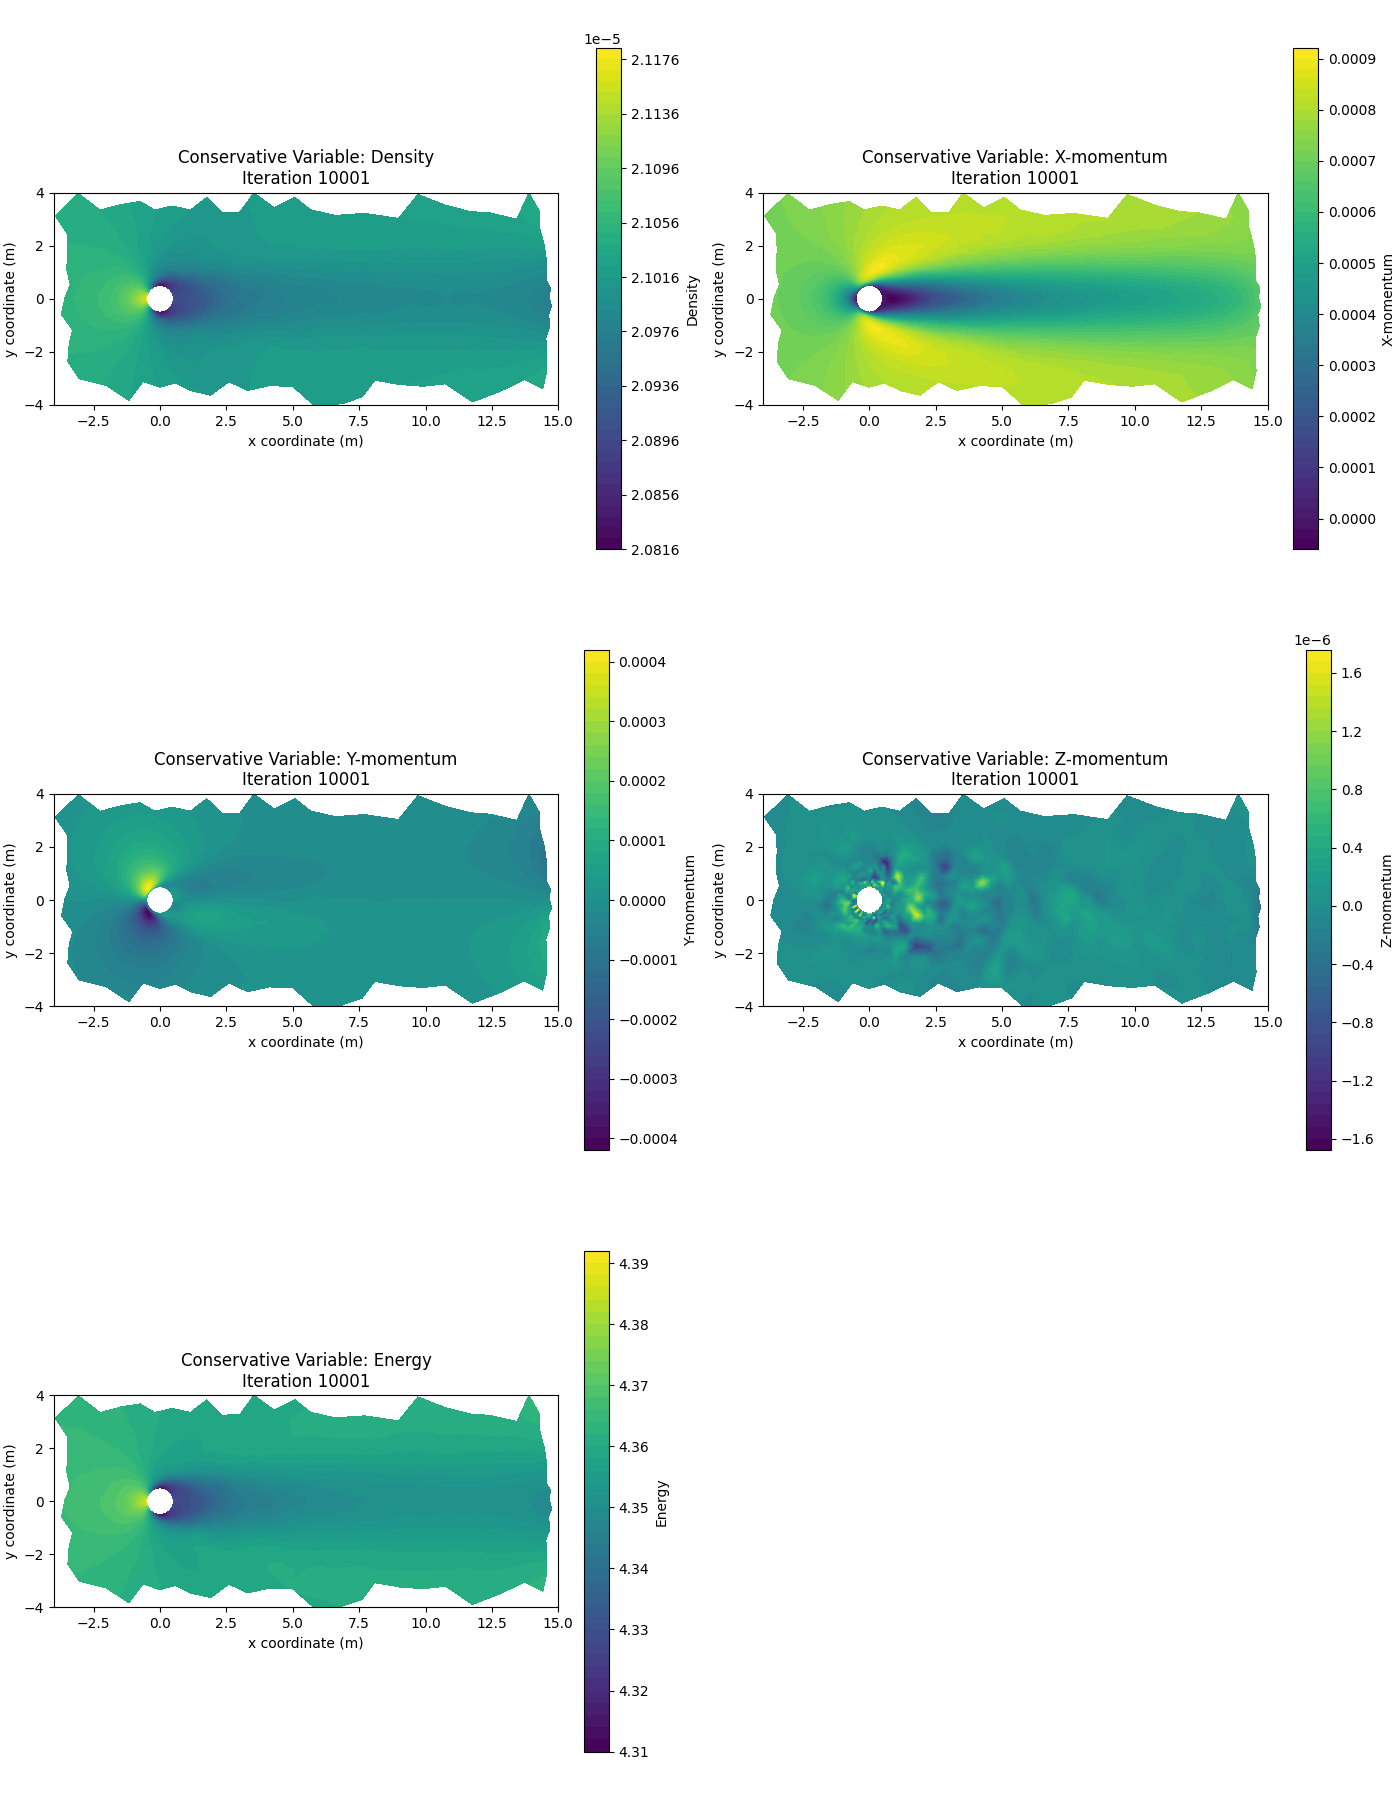

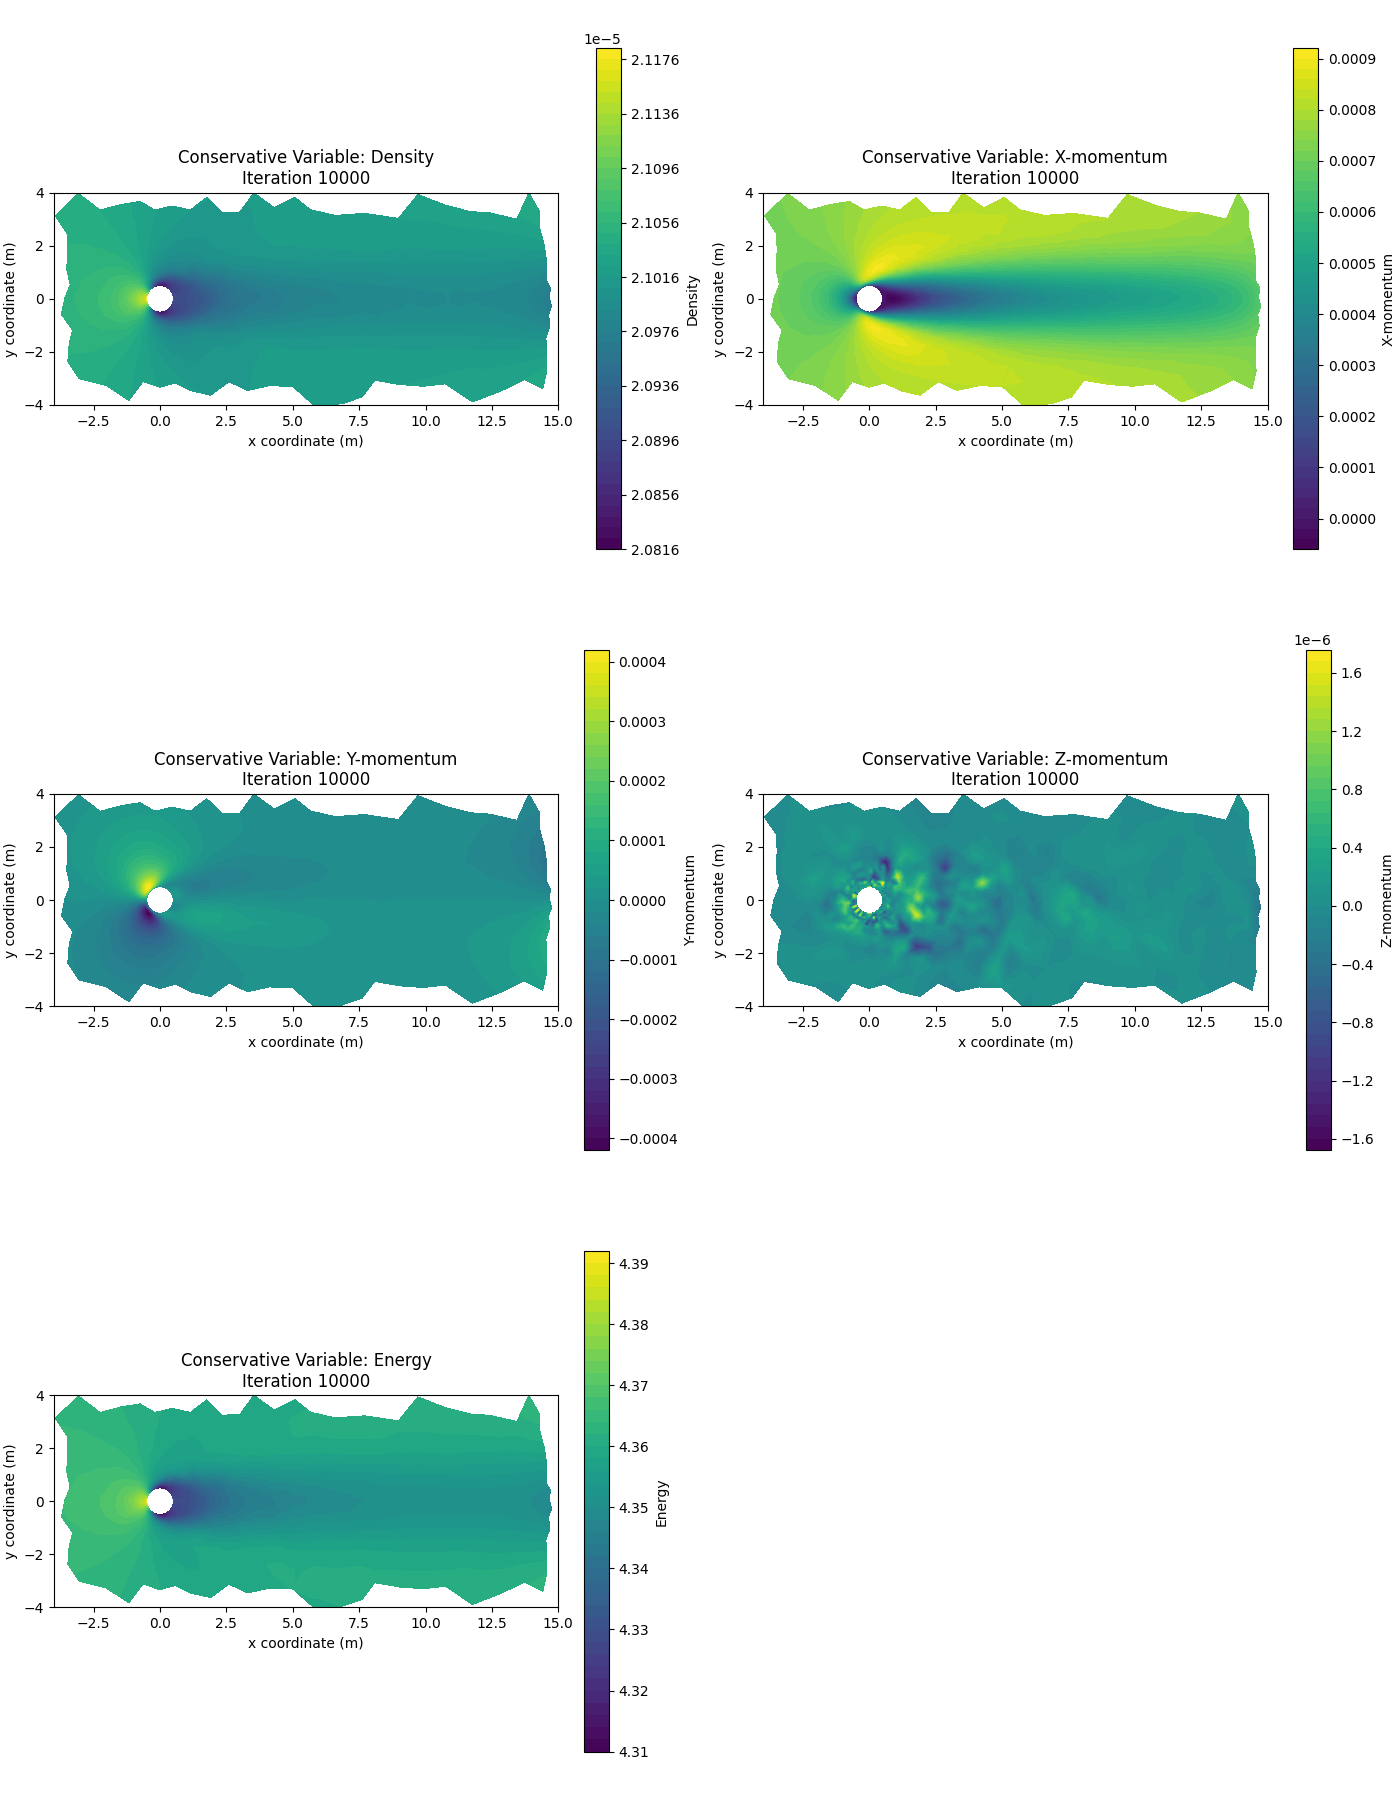

In [586]:
conservative_names = [
    "Density",
    "X-momentum",
    "Y-momentum",
    "Z-momentum",
    "Energy"
]

# plot conservative varialbes at the new iteration
dashboard(
    tri,
    U_new,
    conservative_names,
    iter_rst_new,
    node_filter,
    title_prefix="Conservative Variable",
    x_bounds=X_BOUNDS,
    y_bounds=Y_BOUNDS
)

# plot conservative varialbes at the old iteration
dashboard(
    tri,
    U_old,
    conservative_names,
    iter_rst_old,
    node_filter,
    title_prefix="Conservative Variable",
    x_bounds=X_BOUNDS,
    y_bounds=Y_BOUNDS
)


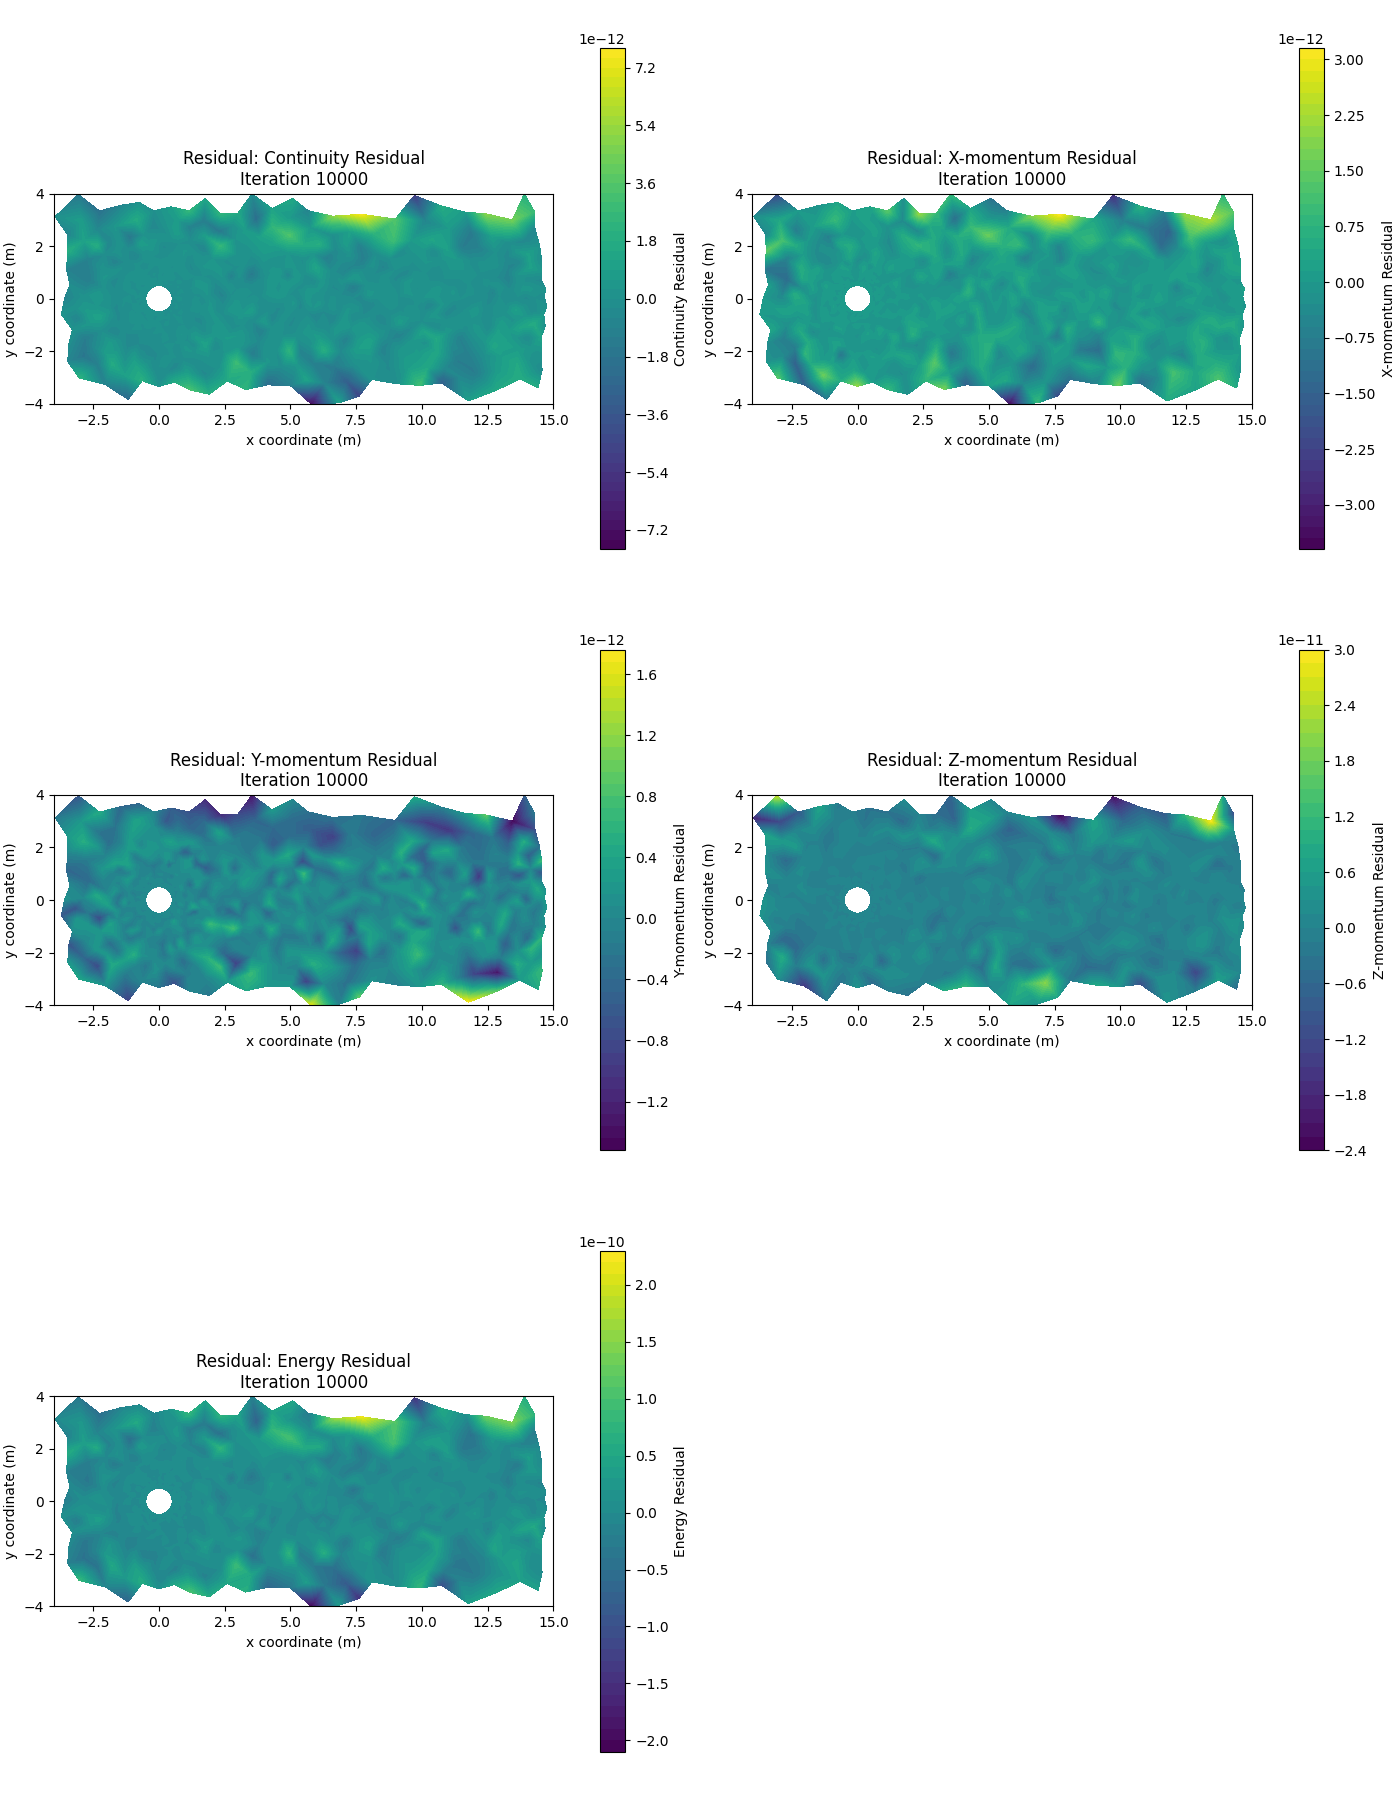

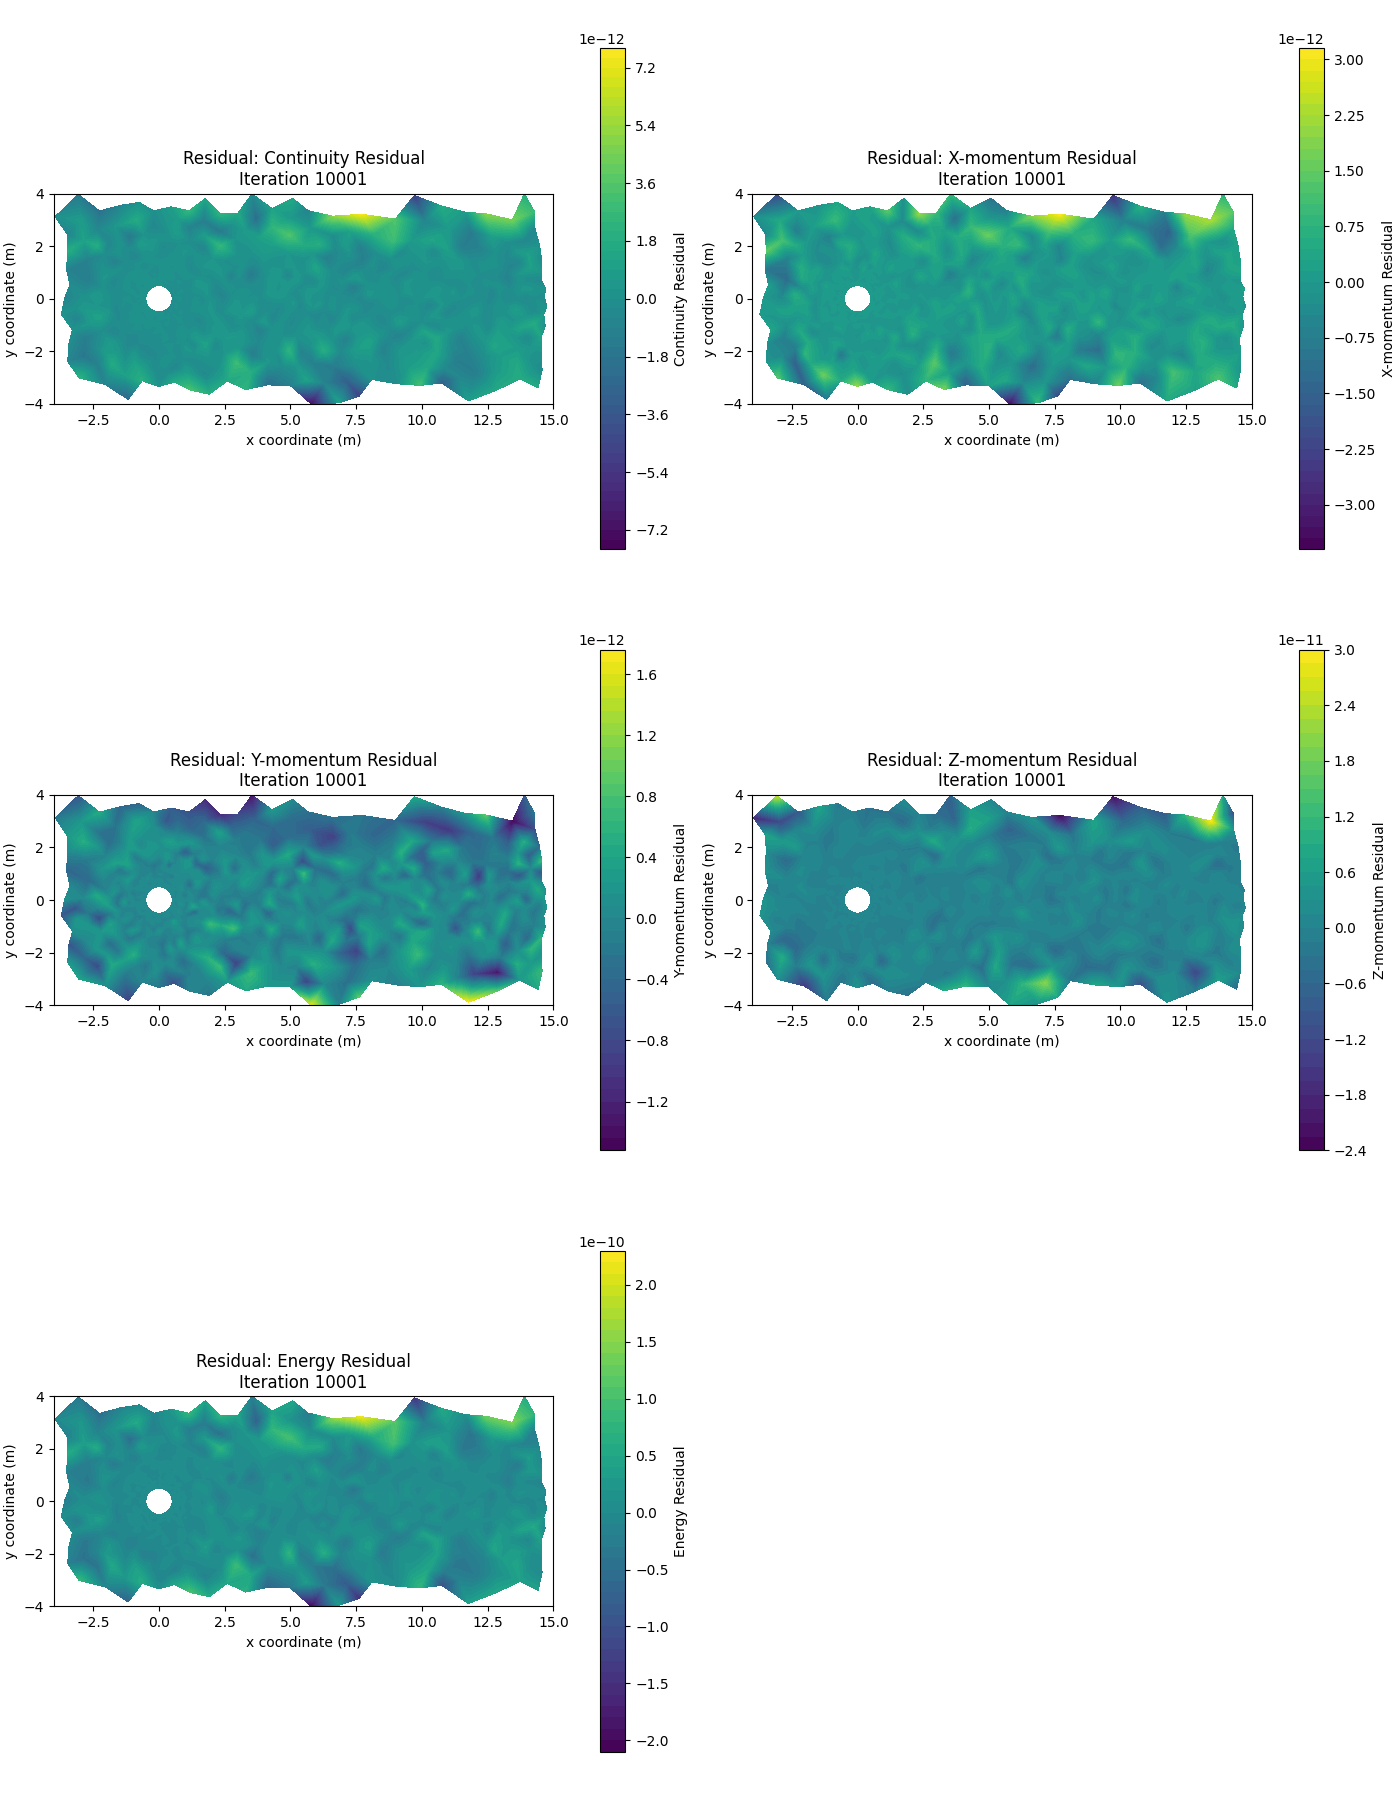

In [587]:

# ============================================================
# Verify: RHS residuals (2 columns x 3 rows)
# ============================================================

residual_names = [
    "Continuity Residual",
    "X-momentum Residual",
    "Y-momentum Residual",
    "Z-momentum Residual",
    "Energy Residual"
]

dashboard(
    tri,
    rhs_old,
    residual_names,
    iter_rhs_old,
    node_filter,
    title_prefix="Residual",
    x_bounds=X_BOUNDS,
    y_bounds=Y_BOUNDS
)

dashboard(
    tri,
    rhs_new,
    residual_names,
    iter_rhs_new,
    node_filter,
    title_prefix="Residual",
    x_bounds=X_BOUNDS,
    y_bounds=Y_BOUNDS
)


/tmp/ipykernel_184124/1614829440.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  J_raw = pd.read_csv(


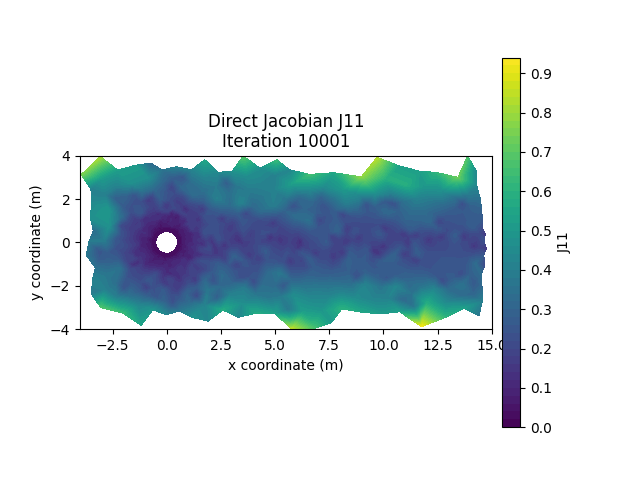

In [588]:
# ============================================================
# Direct Jacobian plotting
# ============================================================

if PLOT_DIRECT_JACOBIAN:

    # Extract iteration number
    iter_jac = extract_iteration(JACOBIAN_FILE)

    # Read direct Jacobian
    J_direct = read_direct_jacobian(JACOBIAN_FILE)

    # ---- Plot single component ----
    plot_jacobian_component(
        tri=tri,
        J=J_direct,
        side_nodes=side_nodes,
        node_filter=node_filter,
        J_row=J_ROW,
        J_col=J_COL,
        iteration=iter_jac,
        x_bounds=X_BOUNDS,
        y_bounds=Y_BOUNDS,
        scale=False,
        tag="Direct"
    )

    # ---- OPTIONAL: plot all 25 components ----
    # for J_row in range(1, 6):
    #     for J_col in range(1, 6):
    #         plot_jacobian_component(
    #             tri,
    #             J_direct,
    #             side_nodes,
    #             node_filter,
    #             J_row,
    #             J_col,
    #             iter_jac,
    #             X_BOUNDS,
    #             Y_BOUNDS,
    #             scale=True,
    #             tag="Direct"
    #         )


In [589]:
# ============================================================
# Jacobian via finite differencing
# ============================================================

delta_rhs = rhs_new - rhs_old
delta_U = U_new - U_old

# J shape: (N, 5, 5)
J = (delta_rhs[:, :, None]+EPS) / (delta_U[:, None, :]+EPS)

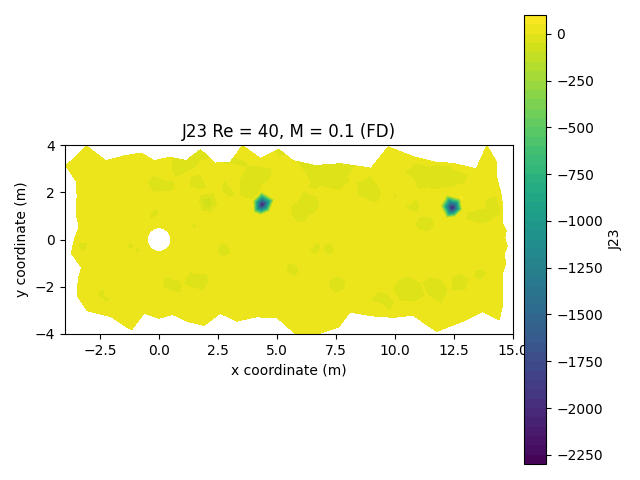

In [ ]:
# ============================================================
# Plot selected Jacobian component
# ============================================================
i = J_ROW - 1
j = J_COL - 1

J_component = J[:, i, j]

plot_scalar_on_surface(
    tri, J_component, 
    node_filter, 
    title=f"J{J_ROW}{J_COL} Re = 40, M = 0.1 (FD)", 
    label=f"J{J_ROW}{J_COL}", 
    x_bounds=X_BOUNDS, 
    y_bounds=Y_BOUNDS )

In [ ]:
# Compute the error of a particular J component

error_abs = np.abs(J_component - J_direct[:,i,j][side_nodes])   # shape (N, 5, 5)

err_L2 = np.sqrt(np.mean(error_abs[error_abs <1]**2, axis=0))   # shape (5, 5)
print("L2 norm error: ",err_L2 )


L2 norm error:  0.7918775689563755
